<a href="https://colab.research.google.com/github/nisha-muthurajan/LCA/blob/main/recommendationLCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn==1.6.1


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import joblib
import shap

In [ ]:
df = pd.read_csv("/content/recommendations_train.csv")
df.head()


,energy_kwh,water_liters,raw_material_tons,co2_kg,waste_kg,impact_score,recommendation_label
0,1200,500,20,820,150,78,energy_optimization
1,900,300,15,430,80,45,recycling_material
2,1600,700,25,1200,300,92,process_efficiency
3,1100,400,18,600,120,60,water_reduction
4,1400,650,22,980,260,85,energy_optimization


In [ ]:
X = df[
    [
        "energy_kwh",
        "water_liters",
        "raw_material_tons",
        "co2_kg",
        "waste_kg",
        "impact_score"
    ]
]

y = df["recommendation_label"]


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:", label_encoder.classes_)


Encoded classes: ['energy_optimization' 'process_efficiency' 'recycling_material'
 'water_reduction']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Model Accuracy: 100.0 %

Classification Report:
                     precision    recall  f1-score   support

energy_optimization       1.00      1.00      1.00         2
 process_efficiency       1.00      1.00      1.00         1
 recycling_material       1.00      1.00      1.00         2
    water_reduction       1.00      1.00      1.00         1

           accuracy                           1.00         6
          macro avg       1.00      1.00      1.00         6
       weighted avg       1.00      1.00      1.00         6



In [ ]:
joblib.dump(model, "recommendation_model.pkl")
joblib.dump(label_encoder, "recommendation_encoder.pkl")

print("Models saved successfully!")


Models saved successfully!


In [ ]:
from google.colab import files

files.download("recommendation_model.pkl")
files.download("recommendation_encoder.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample = pd.DataFrame([{
    "energy_kwh": 1500,
    "water_liters": 700,
    "raw_material_tons": 24,
    "co2_kg": 1050,
    "waste_kg": 280,
    "impact_score": 88
}])

pred = model.predict(sample)
label = label_encoder.inverse_transform(pred)

print("AI Recommendation:", label[0])


AI Recommendation: energy_optimization


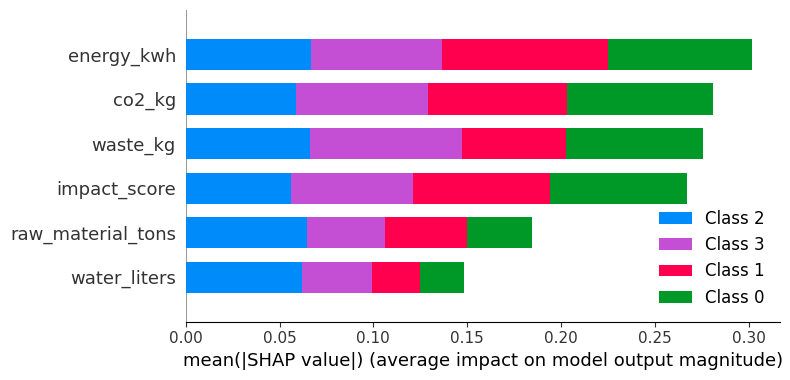

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar")
